In [2]:
import sys
print(sys.executable)

C:\Python314\python.exe


Best Individual: [-0.00037764146056608577, 0.000464257118626119, 0.0007390746276630372, -2.364807780738185e-05, 9.022651160203764e-05]
Best Fitness Value: 9.130791051686265e-07


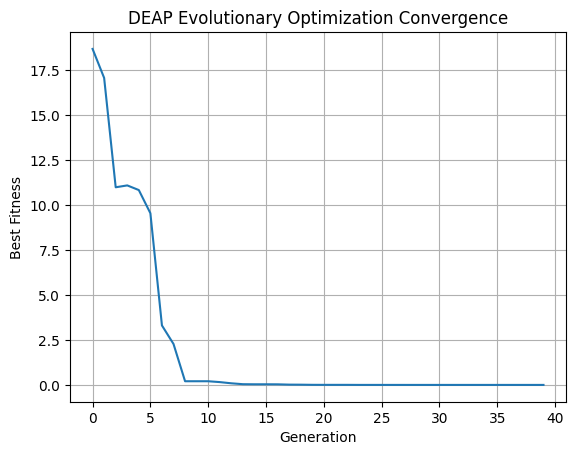

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

# -----------------------------
# Step 1: Define Optimization Problem
# (Sphere Function Minimization)
# -----------------------------
def evaluate(individual):
    return sum(x**2 for x in individual),

# -----------------------------
# Step 2: Create Fitness & Individual
# -----------------------------
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# -----------------------------
# Step 3: Toolbox Setup
# -----------------------------
toolbox = base.Toolbox()

toolbox.register("attr_float", random.uniform, -10, 10)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)

# -----------------------------
# Step 4: Initialize Population
# -----------------------------
population = toolbox.population(n=50)

generations = 40
cx_prob = 0.7
mut_prob = 0.2

best_fitness = []

# -----------------------------
# Step 5: Evolutionary Loop
# -----------------------------
for gen in range(generations):

    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

    # Crossover
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < cx_prob:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() < mut_prob:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Evaluate new individuals
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid_ind:
        ind.fitness.values = toolbox.evaluate(ind)

    # Replace population
    population[:] = offspring

    # Store best fitness
    fits = [ind.fitness.values[0] for ind in population]
    best_fitness.append(min(fits))

# -----------------------------
# Step 6: Results
# -----------------------------
best_individual = tools.selBest(population, 1)[0]

print("Best Individual:", best_individual)
print("Best Fitness Value:", best_individual.fitness.values[0])

# -----------------------------
# Step 7: Convergence Plot
# -----------------------------
plt.figure()

plt.plot(best_fitness)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("DEAP Evolutionary Optimization Convergence")

plt.grid()
plt.show()